In [8]:
"""
멀티모달 RAG - "보기" 전략
이미지를 텍스트로 변환하지 않고 그대로 저장.
질문이 들어오면 관련 페이지를 찾아서 Gemma4가 직접 보면서 답변.
 
저장 구조:
  page_store/          ← 이미지 원본 보관
    p001.png
    p002.png
    ...
  index.json           ← 페이지별 메타 + 텍스트 요약 (검색용)
  ChromaDB             ← 텍스트 요약 벡터 (페이지 후보 검색용)
  
질문 흐름:
  질문 → 텍스트 벡터 검색 → 후보 페이지 이미지 꺼내기
       → Gemma4가 이미지 보면서 답변
"""
 
import ollama
import chromadb
import json
import base64
import shutil
from pathlib import Path

In [9]:
MAIN_DIR = "/data/manual/network_test"
PARSED_DIR  = f"{MAIN_DIR}/parsed_output"       # pdf_parser.py 출력 폴더
STORE_DIR   = f"{PARSED_DIR}/pages"          # 이미지 보관 폴더
VLM_MODEL   = "gemma4:latest"       # 멀티모달 모델
EMBED_MODEL = "embeddinggemma"    # 텍스트 임베딩 (검색용)
COLLECTION  = "page_index"
TOP_K       = 3                     # 질문당 참조할 페이지 수

In [10]:
# ── STEP 1: 인덱싱 ─────────────────────────────────────────────────────────────
# 텍스트 페이지는 텍스트 그대로, 시각 페이지는 가벼운 요약만 만들어 저장.
# 이미지 자체는 변환 없이 page_store/에 복사.
 
PROMPT_SUMMARY = """이 페이지를 한 문단으로 요약해줘.
무엇이 담겨 있는지만 설명하면 돼. 상세 내용은 필요 없어.
예) "3계층 네트워크 구조도. Core Router, Distribution Switch, 서버 3대의 연결 관계를 보여줌."
"""
 
def build_summary_for_page(image_path: str) -> str:
    """VLM으로 페이지 요약 생성 - 검색 인덱스용 (짧게)"""
    with open(image_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    resp = ollama.chat(
        model=VLM_MODEL,
        messages=[{"role": "user", "content": PROMPT_SUMMARY, "images": [b64]}]
    )
    return resp["message"]["content"].strip()
 
 
def build_index(parsed_dir: str = PARSED_DIR, store_dir: str = STORE_DIR):
    """
    인덱스 구축:
    - 텍스트 페이지: full_text에서 텍스트 사용 (VLM 호출 없음)
    - 시각/혼합 페이지: VLM으로 짧은 요약만 생성 (전체 변환 X)
    - 이미지는 page_store/에 복사 (원본 보존)
    """
    base  = Path(parsed_dir)
    store = Path(store_dir)
    store.mkdir(exist_ok=True)
 
    # vlm_queue.json + full_text.txt 로드
    queue     = json.loads((base / "vlm_queue.json").read_text())
    full_text = (base / "full_text.txt").read_text(encoding="utf-8")
    summary   = json.loads((base / "summary.json").read_text())
 
    # full_text에서 페이지별 텍스트 파싱
    import re
    blocks    = re.split(r"={60}\n\[PAGE (\d+)\] \((\w+)\)\n={60}", full_text)
    text_map  = {}  # page_num → text
    i = 1
    while i + 2 < len(blocks):
        text_map[int(blocks[i])] = (blocks[i+1], blocks[i+2].strip())
        i += 3
 
    # ChromaDB 초기화 - PersistentClient로 디스크에 저장
    chroma_path = str(Path(parsed_dir) / "chroma_db")
    client = chromadb.PersistentClient(path=chroma_path)
    try:
        client.delete_collection(COLLECTION)
    except Exception:
        pass
    col = client.create_collection(COLLECTION)
 
    # vlm_queue에 없는 페이지 = text 전용
    visual_pages = {e["page_num"] for e in queue}
    all_pages    = summary["page_count"]
 
    index_records = []
    print(f"📦 인덱스 구축 중 ({all_pages}페이지)...")
 
    for page_num in range(1, all_pages + 1):
        ptype, text = text_map.get(page_num, ("text", ""))
        render_src  = base / "pages" / f"p{page_num:03d}.png"
        img_dest    = store / f"p{page_num:03d}.png"
 
        # 이미지 원본 복사 (항상)
        if render_src.exists() and render_src.resolve() != img_dest.resolve() and not img_dest.exists():
            shutil.copy2(render_src, img_dest)
 
        if page_num not in visual_pages:
            # 텍스트 페이지: 텍스트 그대로 인덱싱, VLM 호출 없음
            search_text = text or f"페이지 {page_num}"
            print(f"  p{page_num:03d} [text]   → 텍스트 인덱싱")
        else:
            # 시각/혼합 페이지: 짧은 요약만 생성
            print(f"  p{page_num:03d} [{ptype}] → 요약 생성 중...", end=" ", flush=True)
            search_text = build_summary_for_page(str(img_dest))
            print(f"완료")
 
        # 벡터 DB에 저장 (검색용 텍스트 + 메타)
        embed = ollama.embeddings(model=EMBED_MODEL, prompt=search_text)
        col.add(
            ids        = [f"p{page_num:03d}"],
            embeddings = [embed["embedding"]],
            documents  = [search_text],
            metadatas  = [{
                "page_num":  page_num,
                "page_type": ptype,
                "img_path":  str(img_dest),
                "has_image": render_src.exists(),
            }],
        )
 
        index_records.append({
            "page_num":    page_num,
            "page_type":   ptype,
            "img_path":    str(img_dest),
            "search_text": search_text,
        })
 
    # 인덱스 JSON 저장 (디버깅용)
    (store / "index.json").write_text(
        json.dumps(index_records, ensure_ascii=False, indent=2)
    )
    print(f"\n✅ 인덱스 완료: {store_dir}/index.json")
    return col

In [11]:
# ── STEP 2: 질문-답변 ─────────────────────────────────────────────────────────
# 텍스트 검색으로 후보 페이지를 찾은 뒤,
# Gemma4가 해당 페이지 이미지를 직접 보면서 답변.
 
from PIL import Image, ImageDraw
import io, re as _re
 
# ── 프롬프트: 답변 + 근거 영역 좌표를 동시에 요청 ────────────────────────────
 
PROMPT_ANSWER = """다음 질문에 답해줘.
 
질문: {question}
 
반드시 아래 JSON 형식으로만 답해줘. 다른 텍스트는 쓰지 마.
{{
  "answer": "질문에 대한 답변 텍스트",
  "evidence": [
    {{
      "description": "이 영역이 근거인 이유",
      "x1": 0.0,
      "y1": 0.0,
      "x2": 1.0,
      "y2": 1.0
    }}
  ]
}}
 
규칙:
- evidence는 답변 근거가 된 이미지 영역을 비율(0.0~1.0)로 표시
- 근거 영역이 여러 개면 배열에 모두 포함
- 이미지에 없는 내용은 추측하지 마
- 근거를 찾지 못하면 evidence를 빈 배열로
"""
 
 
# ── 근거 영역 크롭 + 하이라이트 ──────────────────────────────────────────────
 
def crop_evidence(img_path: str, evidence: list[dict],
                  padding: float = 0.02) -> list[Image.Image]:
    """
    근거 영역을 크롭해서 반환.
    여러 근거가 있으면 각각 크롭.
    padding: 크롭 시 여백 비율 (너무 빡빡하지 않게)
    """
    img = Image.open(img_path).convert("RGBA")
    W, H = img.size
    crops = []
 
    for ev in evidence:
        # 패딩 추가 + 경계 클램프
        x1 = max(0.0, ev["x1"] - padding)
        y1 = max(0.0, ev["y1"] - padding)
        x2 = min(1.0, ev["x2"] + padding)
        y2 = min(1.0, ev["y2"] + padding)
 
        px1, py1 = int(x1 * W), int(y1 * H)
        px2, py2 = int(x2 * W), int(y2 * H)
 
        # 크롭
        crop = img.crop((px1, py1, px2, py2)).convert("RGB")
        crops.append(crop)
 
    return crops
 
 
def highlight_on_page(img_path: str, evidence: list[dict]) -> Image.Image:
    """
    전체 페이지 이미지에 근거 영역 하이라이트 표시.
    여러 근거가 있으면 번호로 구분.
    """
    img = Image.open(img_path).convert("RGBA")
    W, H = img.size
    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
 
    colors = [
        (255, 200,   0),  # 노랑
        ( 50, 180, 255),  # 파랑
        ( 80, 220, 120),  # 초록
    ]
 
    for i, ev in enumerate(evidence):
        r, g, b = colors[i % len(colors)]
        x1, y1 = int(ev["x1"] * W), int(ev["y1"] * H)
        x2, y2 = int(ev["x2"] * W), int(ev["y2"] * H)
 
        # 반투명 채우기
        draw.rectangle([x1, y1, x2, y2], fill=(r, g, b, 70))
        # 테두리
        draw.rectangle([x1, y1, x2, y2], outline=(r, g, b, 230), width=3)
        # 번호 라벨
        label = f" ① ② ③"[i * 2: i * 2 + 3].strip() if i < 3 else str(i + 1)
        draw.rectangle([x1, y1, x1 + 22, y1 + 18], fill=(r, g, b, 220))
        draw.text((x1 + 4, y1 + 2), label, fill=(0, 0, 0, 255))
 
    return Image.alpha_composite(img, overlay).convert("RGB")
 
 
# ── 메인 ask 함수 ──────────────────────────────────────────────────────────────
 
def ask(col, question: str, top_k: int = TOP_K,
        save_dir: str = "rag_results") -> dict:
    """
    1. 벡터 DB로 관련 페이지 검색
    2. VLM이 이미지 보고 답변 + 근거 좌표 반환
    3. 근거 영역 크롭 이미지 생성
    반환값: {answer, evidence_crops, highlighted_page, sources}
    """
    Path(save_dir).mkdir(exist_ok=True)
    q_safe = question[:20].replace(" ", "_")
 
    # [1단계] 벡터 검색
    q_embed = ollama.embeddings(model=EMBED_MODEL, prompt=question)
    results = col.query(
        query_embeddings=[q_embed["embedding"]],
        n_results=top_k,
    )
    metas    = results["metadatas"][0]
    snippets = results["documents"][0]
    print(f"  검색된 페이지: {[m['page_num'] for m in metas]}")
 
    # [2단계] VLM 호출 - 답변 + 근거 좌표 동시 요청
    images, img_paths, source_info = [], [], []
    for meta, snippet in zip(metas, snippets):
        img_path = meta.get("img_path", "")
        if img_path and Path(img_path).exists():
            with open(img_path, "rb") as f:
                images.append(base64.b64encode(f.read()).decode())
            img_paths.append(img_path)
            source_info.append(f"p{meta['page_num']} ({meta['page_type']})")
        else:
            source_info.append(f"p{meta['page_num']} [텍스트] {snippet[:40]}")
 
    prompt = PROMPT_ANSWER.format(question=question)
    msg    = {"role": "user", "content": prompt}
    if images:
        msg["images"] = images
 
    resp = ollama.chat(model=VLM_MODEL, messages=[msg])
    raw  = resp["message"]["content"].strip()
 
    # JSON 파싱 (코드블록 제거 후)
    try:
        clean = _re.sub(r"```json|```", "", raw).strip()
        data  = json.loads(clean)
    except json.JSONDecodeError:
        # 파싱 실패 시 답변만 반환
        return {"answer": raw, "evidence_crops": [], "sources": source_info}
 
    answer   = data.get("answer", "")
    evidence = data.get("evidence", [])
 
    # [3단계] 근거 영역 크롭 + 전체 페이지 하이라이트
    evidence_crops     = []
    highlighted_pages  = []
 
    # 이미지가 1개일 때만 크롭 (여러 페이지면 첫 번째 기준)
    if img_paths and evidence:
        primary_img = img_paths[0]
 
        # 전체 페이지에 하이라이트
        highlighted = highlight_on_page(primary_img, evidence)
        hl_path = f"{save_dir}/{q_safe}_highlighted.jpg"
        highlighted.save(hl_path, quality=95)
        highlighted_pages.append(hl_path)
 
        # 근거 영역별 크롭
        crops = crop_evidence(primary_img, evidence)
        for i, crop in enumerate(crops):
            crop_path = f"{save_dir}/{q_safe}_evidence_{i+1}.jpg"
            crop.save(crop_path, quality=95)
            evidence_crops.append({
                "path":        crop_path,
                "description": evidence[i].get("description", ""),
            })
            print(f"  근거 {i+1}: {evidence[i].get('description', '')} → {crop_path}")
 
    print(f"  답변: {answer[:60]}...")
    return {
        "answer":            answer,
        "evidence_crops":    evidence_crops,
        "highlighted_pages": highlighted_pages,
        "sources":           source_info,
    }

In [12]:
# ── Jupyter 출력용 ────────────────────────────────────────────────────────────
 
def display_answer(result: dict):
    """
    Jupyter Notebook에서 ask() 결과를 시각적으로 출력.
    IPython.display 미설치 환경(일반 Python)에서도 안전하게 동작.
    """
    try:
        from IPython.display import display, Markdown, Image as IPImage
        _jupyter = True
    except ImportError:
        _jupyter = False
 
    answer  = result.get("answer", "")
    sources = ", ".join(result.get("sources", []))
    hl_pages  = result.get("highlighted_pages", [])
    ev_crops  = result.get("evidence_crops", [])
 
    if _jupyter:
        # ── 답변 텍스트 ──
        display(Markdown(f"### 📝 답변\n{answer}"))
        display(Markdown(f"*📄 참조: {sources}*"))
 
        # ── 하이라이트 페이지 (전체 페이지 + 박스) ──
        if hl_pages:
            display(Markdown("---\n#### 🖼️ 근거 페이지"))
            for path in hl_pages:
                display(IPImage(filename=path, width=700))
 
        # ── 근거 크롭 (영역별) ──
        if ev_crops:
            display(Markdown(f"---\n#### ✂️ 근거 영역 ({len(ev_crops)}개)"))
            for i, ev in enumerate(ev_crops, 1):
                display(Markdown(f"**{i}. {ev['description']}**"))
                display(IPImage(filename=ev["path"], width=500))
    else:
        # 일반 Python 폴백
        print(f"\n📝 답변:\n{answer}")
        print(f"\n📄 참조: {sources}")
        if hl_pages:
            print(f"\n🖼️  하이라이트: {hl_pages[0]}")
        for i, ev in enumerate(ev_crops, 1):
            print(f"\n✂️  근거 {i}: [{ev['description']}] → {ev['path']}")

=== 기존 인덱스 로드 ===
  '/data/manual/network_test/parsed_output/chroma_db' 에서 로드됨 (101개 페이지)
  검색된 페이지: [45, 87, 44]
  근거 1: KT 통신사의 기본(Preferred) 및 보조(Alternate) DNS 서버 IP 주소 정보 → rag_results/KT_통신_가입자인데,_DNS_서버__evidence_1.jpg
  답변: 1. **[IP 주소 및 DNS 설정 화면 진입]**:
'제어판' → '네트워크 및 공유 센터' → '어댑터...


### 📝 답변
1. **[IP 주소 및 DNS 설정 화면 진입]**:
'제어판' → '네트워크 및 공유 센터' → '어댑터 설정 변경'으로 이동합니다. 사용 중인 네트워크 연결(예: 이더넷 또는 Wi-Fi)을 마우스 오른쪽 버튼으로 클릭한 후 '속성'을 선택합니다.

2. **[IPv4 설정 변경]**:
속성 창에서 '인터넷 프로토콜 버전 4(TCP/IPv4)'을 선택하고 '속성' 버튼을 클릭합니다.

3. **[DNS 서버 주소 입력]**:
'다음 DNS 서버 주소 사용'을 선택한 후, 아래와 같이 KT 전용 IP 주소를 입력합니다.

*   **기본 DNS 서버(Preferred DNS Server):** `168.126.63.1`
*   **보조 DNS 서버(Alternate DNS Server):** `203.248.252.2`

4. **[적용 및 확인]**:
'확인' 버튼을 눌러 모든 설정 창을 닫아줍니다.

*📄 참조: p45 (mixed), p87 (mixed), p44 (mixed)*

---
#### 🖼️ 근거 페이지

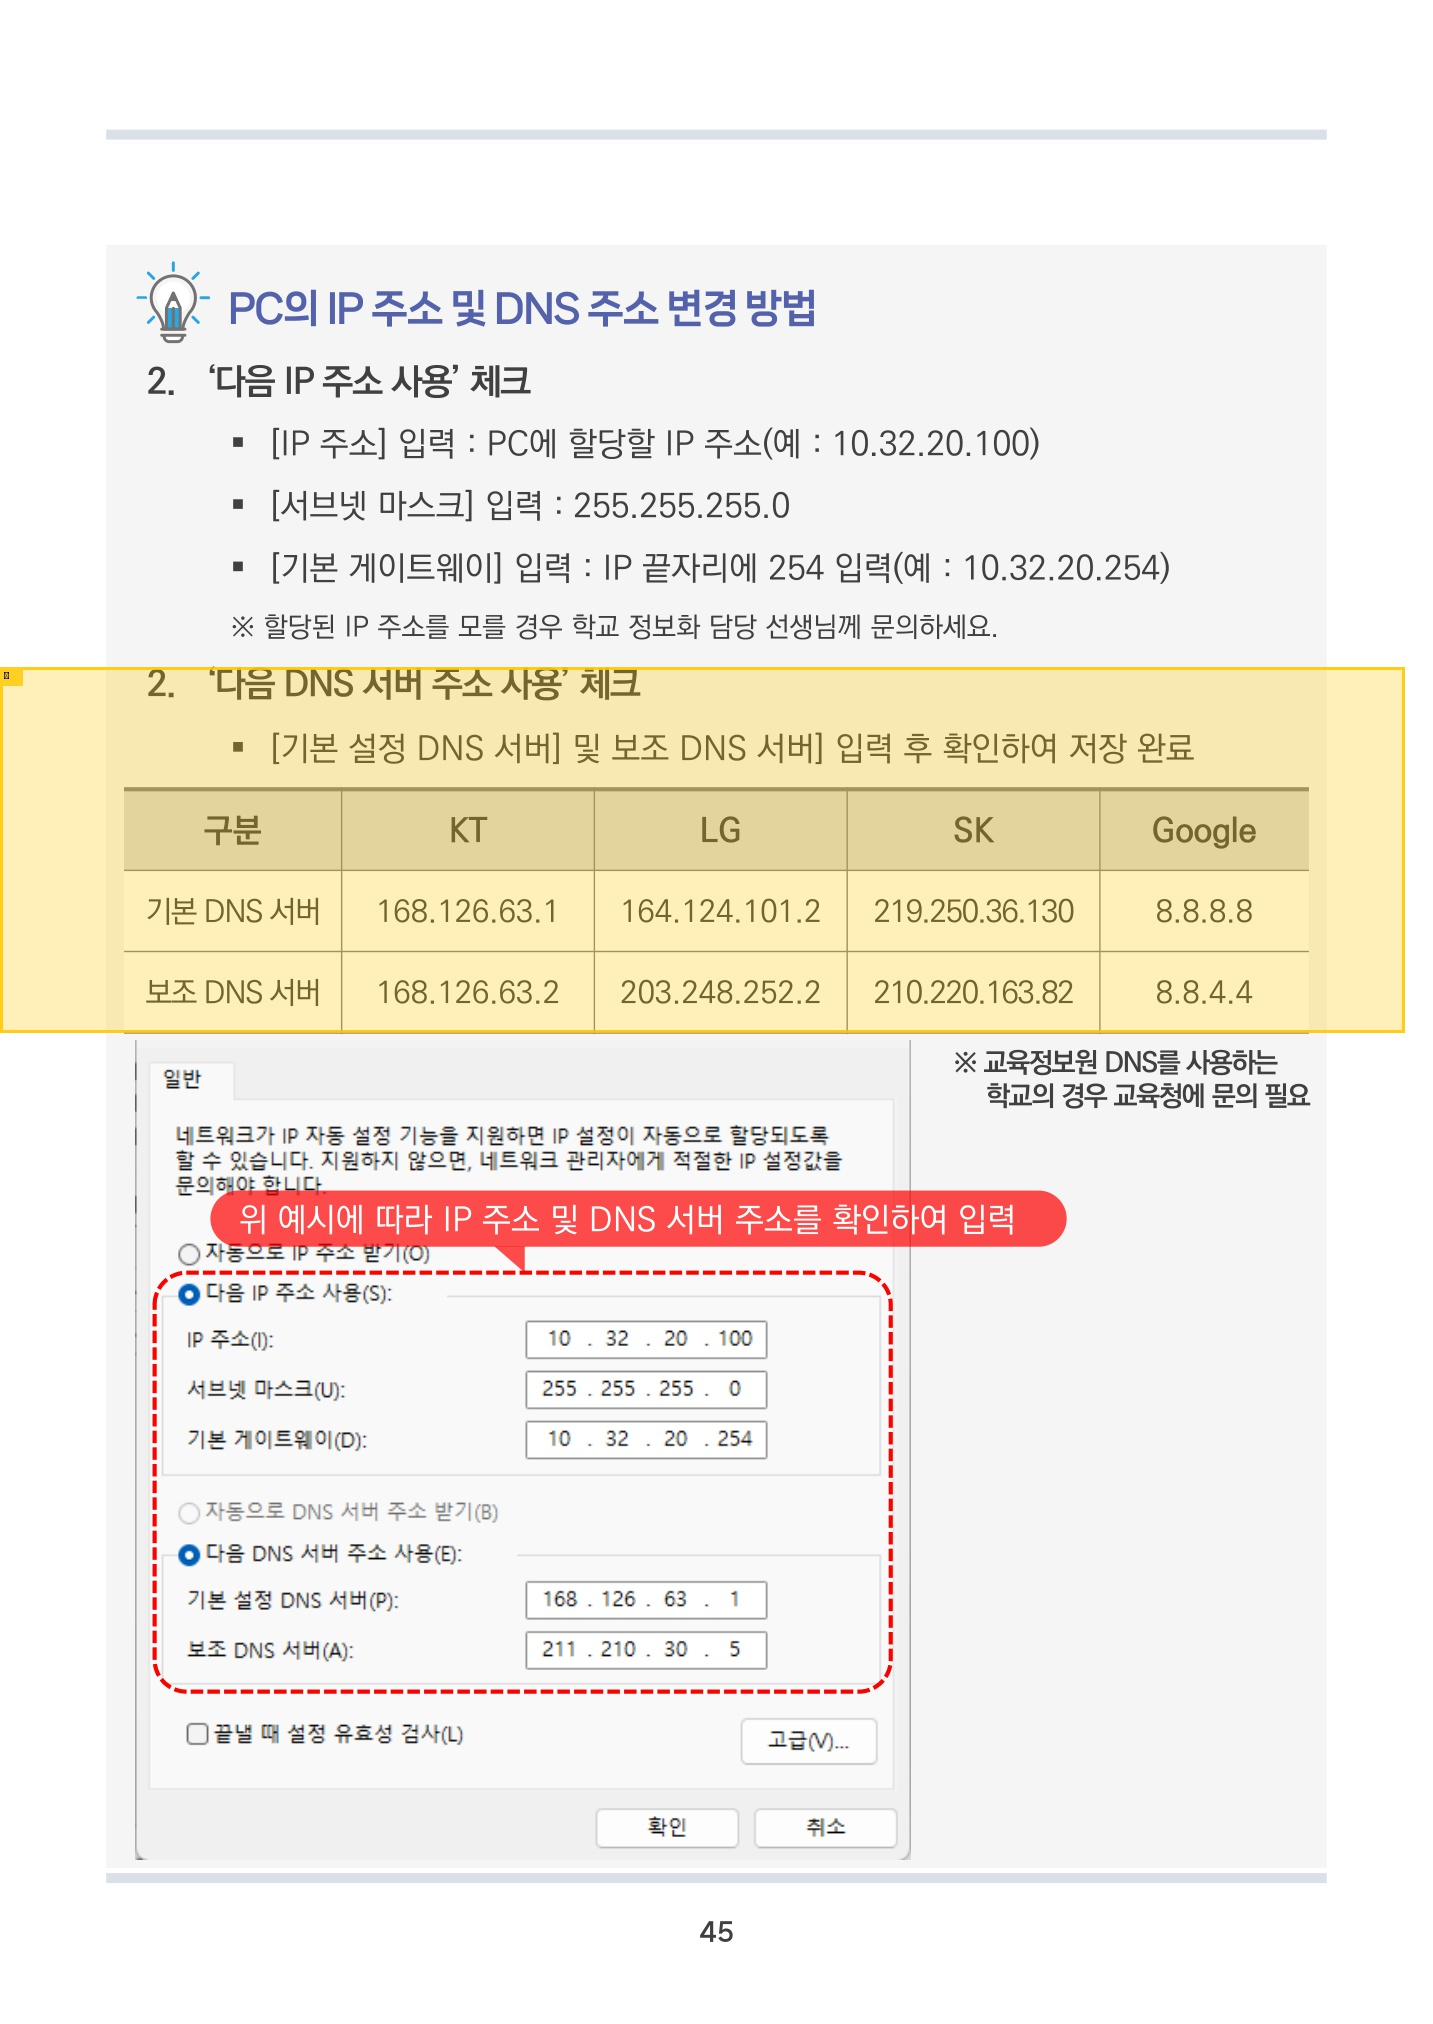

---
#### ✂️ 근거 영역 (1개)

**1. KT 통신사의 기본(Preferred) 및 보조(Alternate) DNS 서버 IP 주소 정보**

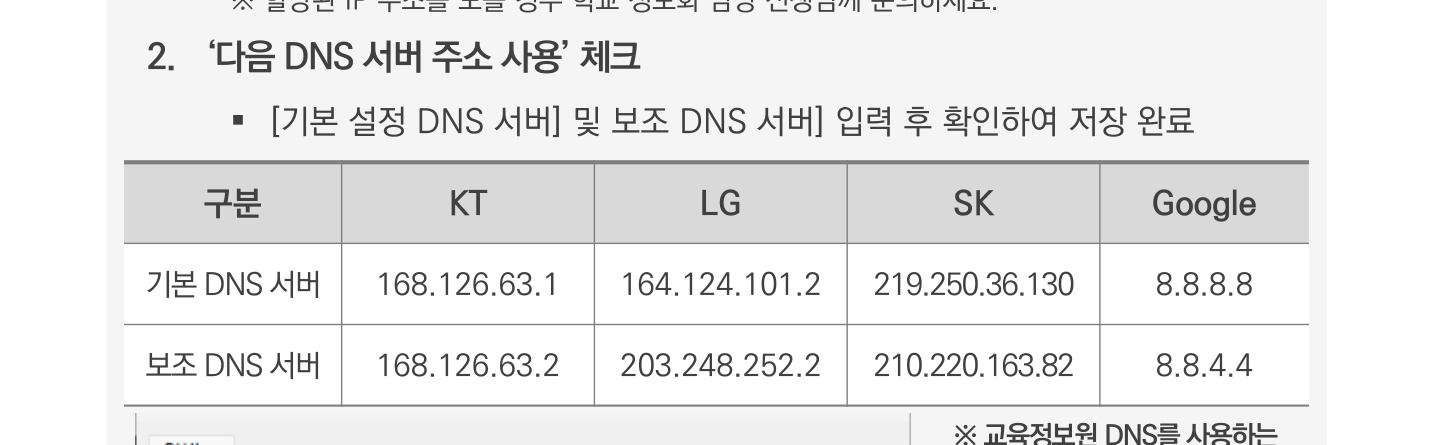

  검색된 페이지: [45, 87, 44]
  근거 1: SK 사용자의 기본 및 보조 DNS 서버 주소가 표에 제시되어 있습니다. → rag_results/SK_사용자는_기본_DNS,_보조_D_evidence_1.jpg
  답변: SK 사용자의 DNS 서버 주소는 다음과 같습니다.
기본 DNS 서버: 219.250.36.130
보조 DN...


### 📝 답변
SK 사용자의 DNS 서버 주소는 다음과 같습니다.
기본 DNS 서버: 219.250.36.130
보조 DNS 서버: 210.220.163.82

*📄 참조: p45 (mixed), p87 (mixed), p44 (mixed)*

---
#### 🖼️ 근거 페이지

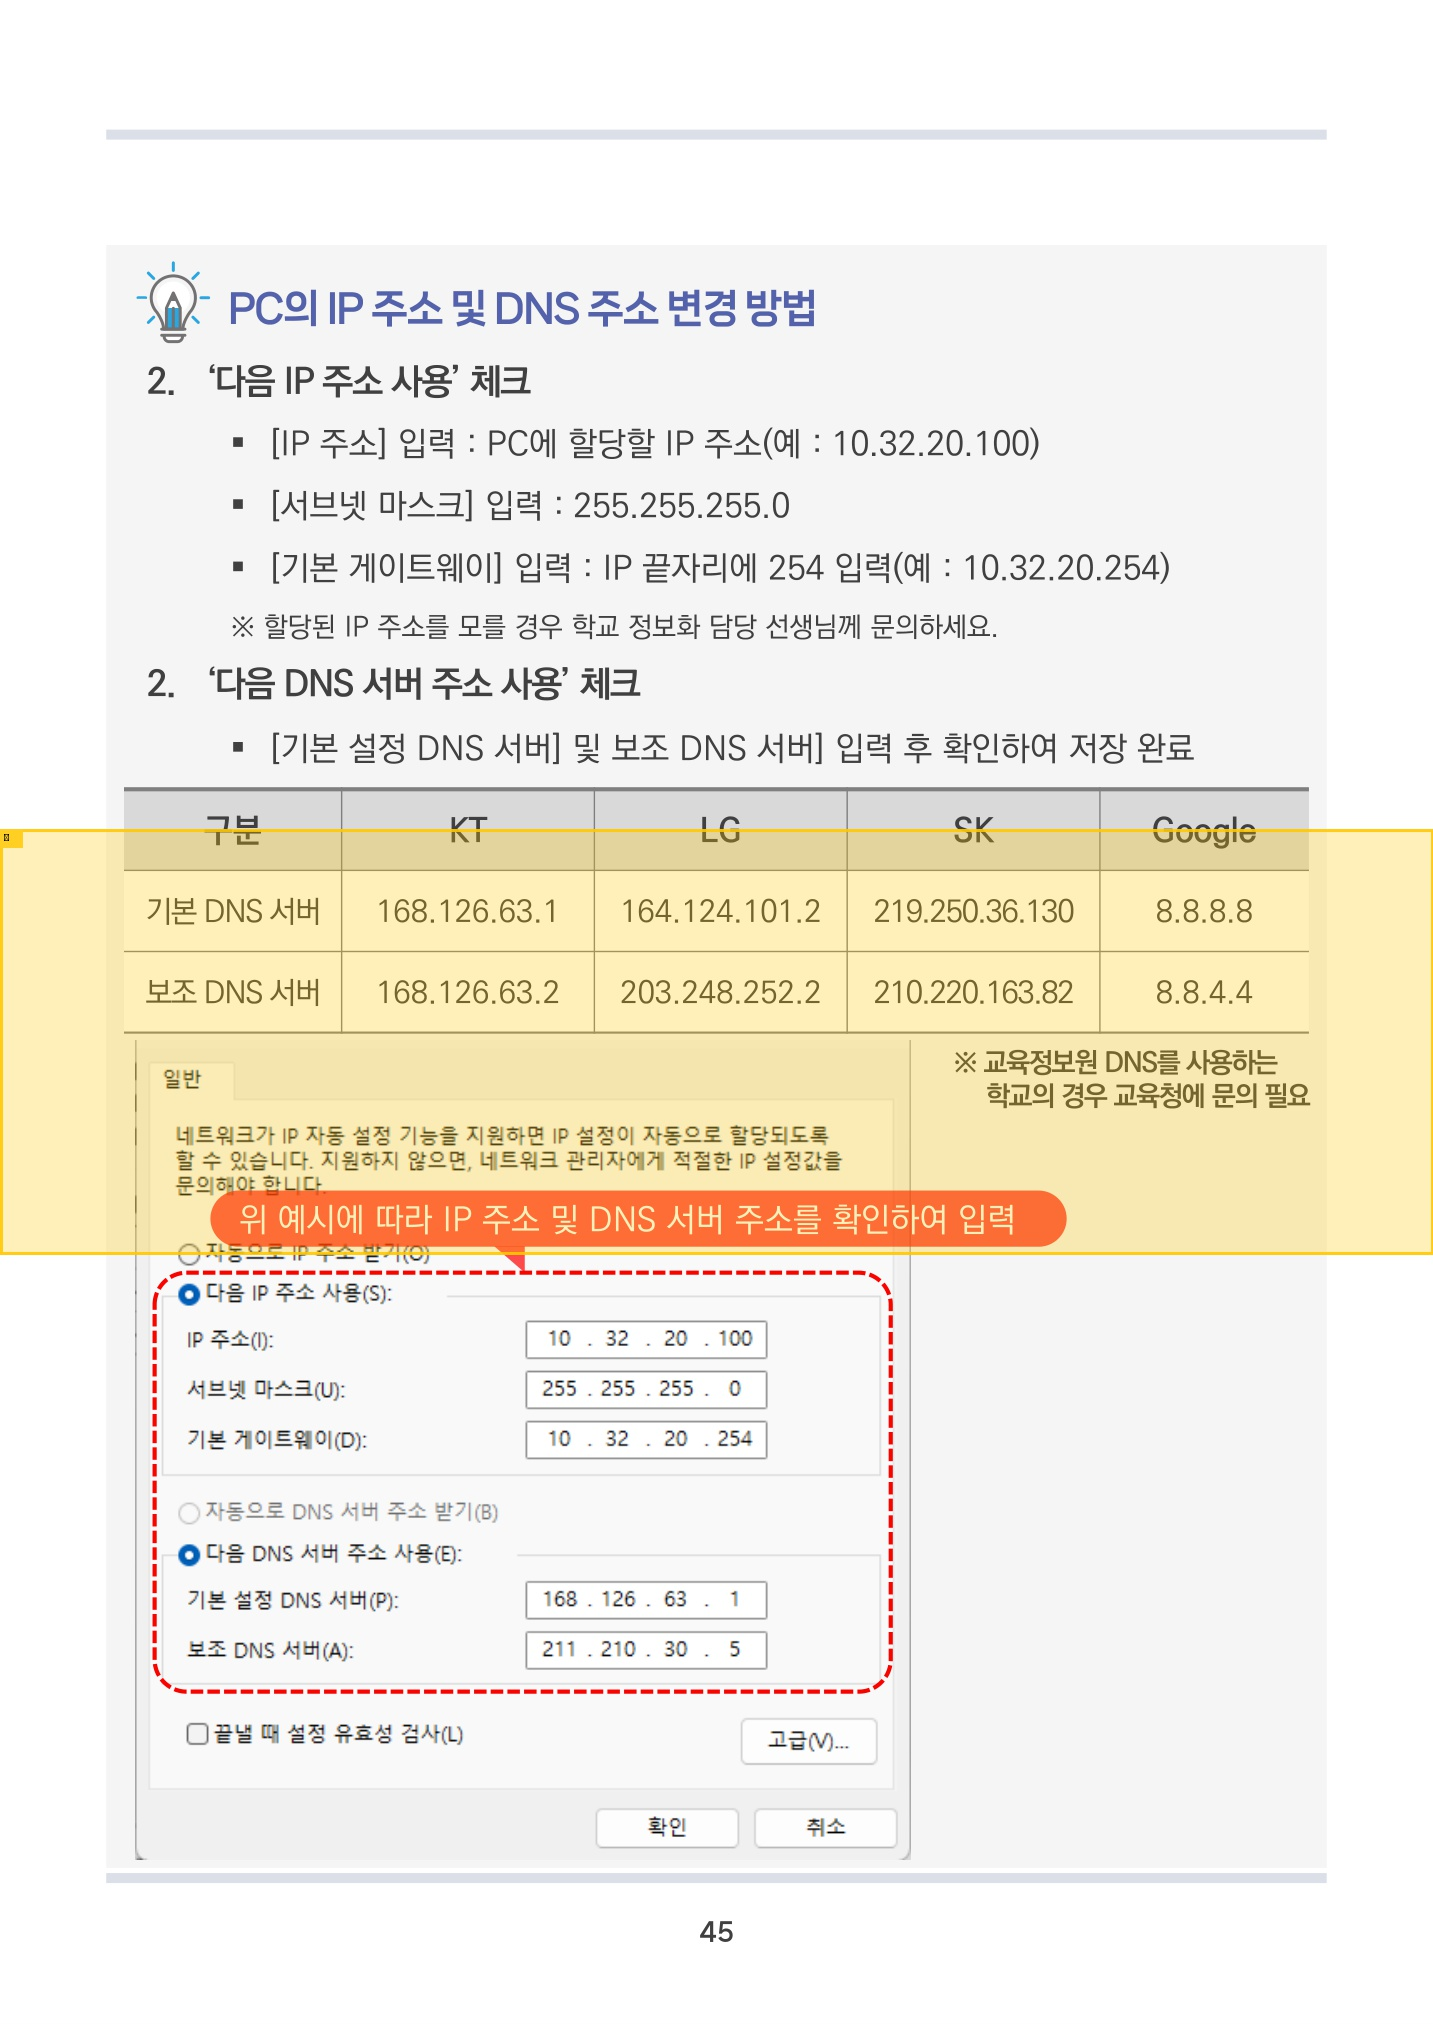

---
#### ✂️ 근거 영역 (1개)

**1. SK 사용자의 기본 및 보조 DNS 서버 주소가 표에 제시되어 있습니다.**

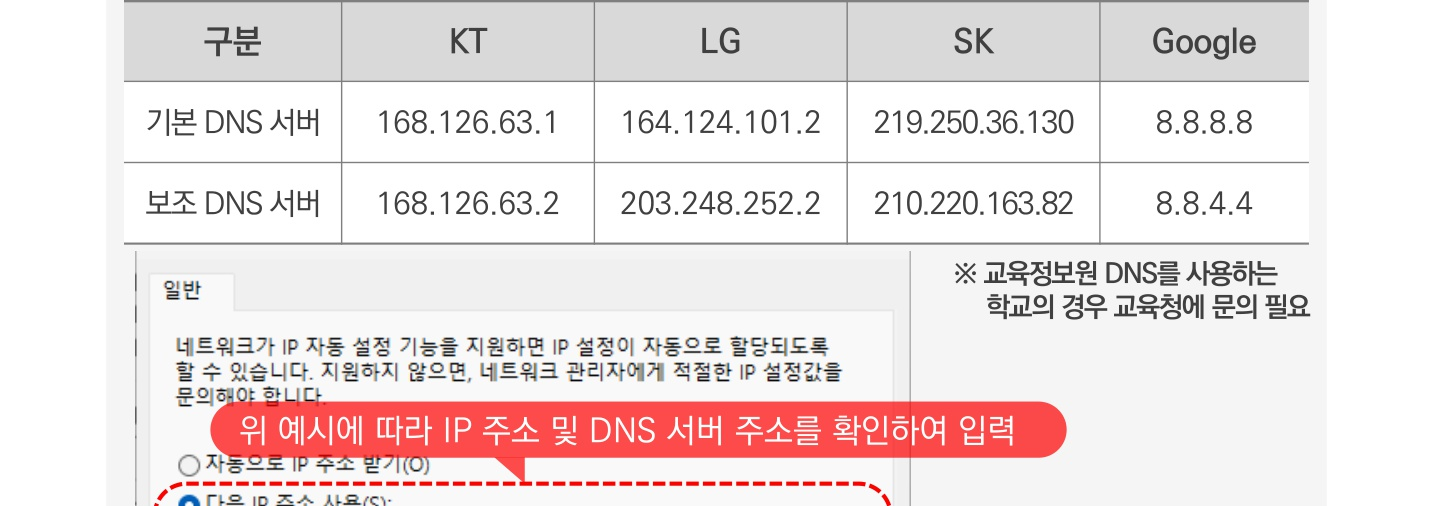

In [14]:
# ── 실행 (일반 Python) ─────────────────────────────────────────────────────────
 
if __name__ == "__main__":
    parsed = Path(PARSED_DIR)
    if not parsed.exists():
        print(f"❌ {PARSED_DIR}/ 없음 - 먼저 pdf_parser.py를 실행하세요")
        exit(1)
 
    store = Path(STORE_DIR)
    if not (store / "index.json").exists():
        print("=== 인덱스 구축 ===")
        col = build_index()
    else:
        print("=== 기존 인덱스 로드 ===")
        chroma_path = str(parsed / "chroma_db")
        client = chromadb.PersistentClient(path=chroma_path)
        col = client.get_collection(COLLECTION)
        print(f"  '{chroma_path}' 에서 로드됨 ({col.count()}개 페이지)")
 
    while True:
        q = input("\n질문 (종료: q): ").strip()
        if q.lower() == "q":
            break
        if q:
            display_answer(ask(col, q))